# EchoCardioNet-Peds
**Automated Ejection Fraction Estimation from Pediatric Echocardiography**

Dataset: EchoNet-Pediatric (Stanford, 2022) — A4C view  
Architecture: ConvDAE → CNNEncoder → BiLSTM → GRU → SparseAE

## 0. Setup

In [1]:
!apt-get install -y ffmpeg > /dev/null 2>&1
!pip install -q opencv-python-headless scikit-learn

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import sys, os

# Solve_2 proje klasörünü MyDrive'a yükledikten sonra bu yolu ayarla
PROJECT_ROOT = '/content/drive/MyDrive/Solve_2'
sys.path.insert(0, PROJECT_ROOT)

# A4C klasörü direkt MyDrive içinde: MyDrive/A4C/FileList.csv
DATA_ROOT = '/content/drive/MyDrive'

CKPT_DIR = '/content/checkpoints'
FIG_DIR  = '/content/figures'
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(FIG_DIR,  exist_ok=True)

import torch
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')
print(f'Project: {PROJECT_ROOT}')
print(f'Data   : {DATA_ROOT}')

Device : cuda
Project: /content/drive/MyDrive/Solve_2
Data   : /content/drive/MyDrive


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score

from model.dataset import EchoDataset, pad_collate
from model.network import EchoCardioNet
from model.train import (
    pretrain_dae, train_full, run_ablation,
    evaluate, evaluate_ablation,
    plot_training_curves, plot_dae_reconstructions,
    plot_scatter, plot_ablation, plot_attention_weights,
    plot_ef_distribution, ABLATION_CONFIGS, AblationModel,
)

print('Imports OK')

Imports OK


## 1. Exploratory Data Analysis

In [5]:
csv_path = os.path.join(DATA_ROOT, 'A4C', 'FileList.csv')
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

train_df = df[df['Split'].isin(range(8))]
val_df   = df[df['Split'] == 8]
test_df  = df[df['Split'] == 9]

print(f'Total : {len(df)}')
print(f'Train / Val / Test : {len(train_df)} / {len(val_df)} / {len(test_df)}')
print(f'EF mean ± std : {df["EF"].mean():.1f} ± {df["EF"].std():.1f}')
print(f'EF min  / max : {df["EF"].min():.1f} / {df["EF"].max():.1f}')

normal = (df['EF'] >= 55).sum()
mild   = ((df['EF'] >= 40) & (df['EF'] < 55)).sum()
dysfun = (df['EF'] < 40).sum()
print(f'Normal (>=55%) : {normal} ({100*normal/len(df):.1f}%)')
print(f'Mild   (40-55%): {mild}   ({100*mild/len(df):.1f}%)')
print(f'Dysfunction    : {dysfun} ({100*dysfun/len(df):.1f}%)')

Total : 3284
Train / Val / Test : 2580 / 336 / 368
EF mean ± std : 60.9 ± 10.5
EF min  / max : 7.0 / 73.0
Normal (>=55%) : 2790 (85.0%)
Mild   (40-55%): 305   (9.3%)
Dysfunction    : 189 (5.8%)


In [6]:
plot_ef_distribution(df, save_path=os.path.join(FIG_DIR, 'eda_ef_distribution.png'))
plt.show()

Saved → /content/figures/eda_ef_distribution.png


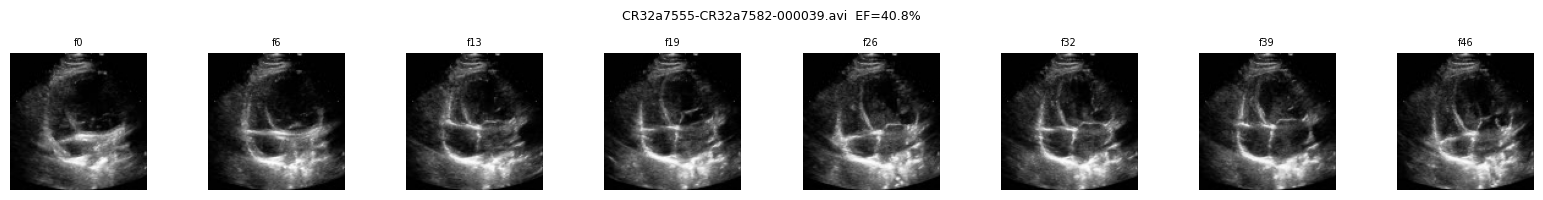

In [7]:
import cv2

sample_row  = train_df.iloc[0]
video_path  = os.path.join(DATA_ROOT, 'A4C', 'Videos', sample_row['FileName'])
cap   = cv2.VideoCapture(video_path)
total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for i, idx in enumerate(np.linspace(0, total - 1, 8, dtype=int)):
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
    ret, frame = cap.read()
    if ret:
        gray = cv2.resize(cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY), (112, 112))
        axes[i].imshow(gray, cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(f'f{idx}', fontsize=7)
cap.release()
plt.suptitle(f"{sample_row['FileName']}  EF={sample_row['EF']:.1f}%", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'eda_sample_frames.png'), dpi=150)
plt.show()

## 2. DataLoaders

In [8]:
BATCH_SIZE = 8

train_ds = EchoDataset(DATA_ROOT, view='A4C', split='train', T=32, augment=True)
val_ds   = EchoDataset(DATA_ROOT, view='A4C', split='val',   T=32, augment=False)
test_ds  = EchoDataset(DATA_ROOT, view='A4C', split='test',  T=32, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=pad_collate, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=pad_collate, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=pad_collate, num_workers=2, pin_memory=True)

print(f'Train batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')
print(f'Test  batches : {len(test_loader)}')

frames, ef, names, lengths = next(iter(train_loader))
print(f'frames  : {frames.shape}   (B, T, C, H, W)')
print(f'ef      : {ef.shape}')
print(f'lengths : {lengths}')

Train batches : 323
Val   batches : 42
Test  batches : 46
frames  : torch.Size([8, 28, 1, 112, 112])   (B, T, C, H, W)
ef      : torch.Size([8])
lengths : tensor([28, 28, 28, 28, 28, 28, 28, 28])


## 3. Phase 1 — DAE Pre-training (10 epochs)

In [9]:
model = EchoCardioNet().to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')

Total parameters: 11,787,554


[DAE] Epoch 01/10  loss=0.03734
[DAE] Epoch 02/10  loss=0.00929
[DAE] Epoch 03/10  loss=0.00709
[DAE] Epoch 04/10  loss=0.00617
[DAE] Epoch 05/10  loss=0.00567
[DAE] Epoch 06/10  loss=0.00533
[DAE] Epoch 07/10  loss=0.00505
[DAE] Epoch 08/10  loss=0.00488
[DAE] Epoch 09/10  loss=0.00465
[DAE] Epoch 10/10  loss=0.00453
DAE checkpoint saved → /content/checkpoints/dae_pretrained.pt


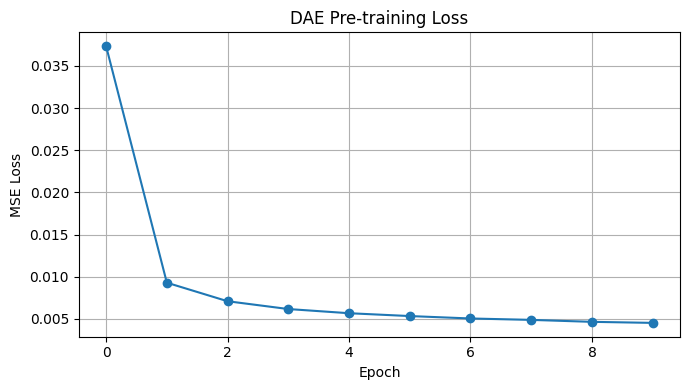

In [10]:
DAE_CKPT = os.path.join(CKPT_DIR, 'dae_pretrained.pt')

dae_history = pretrain_dae(
    model, train_loader,
    epochs=10, lr=3e-4,
    device=DEVICE,
    save_path=DAE_CKPT,
)

plt.figure(figsize=(7, 4))
plt.plot(dae_history, marker='o')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('DAE Pre-training Loss')
plt.grid(True); plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'dae_loss.png'), dpi=150)
plt.show()

In [11]:
plot_dae_reconstructions(
    model, val_loader, device=DEVICE,
    save_path=os.path.join(FIG_DIR, 'dae_reconstructions.png')
)
plt.show()

Saved → /content/figures/dae_reconstructions.png


## 4. Phase 2 — End-to-End Fine-tuning (15 epochs)

In [12]:
# DAE encoder ağırlıklarını CNNEncoder'a aktar
model.transfer_dae_weights()
print('Weight transfer done.')

DAE weights transferred to CNNEncoder conv_blocks.
Weight transfer done.


In [13]:
FULL_CKPT = os.path.join(CKPT_DIR, 'model_F_full.pt')

history = train_full(
    model, train_loader, val_loader,
    epochs=15,
    device=DEVICE,
    save_path=FULL_CKPT,
)

[Train] Epoch 01/15  loss=231.7520  val_MAE=6.584
[Train] Epoch 02/15  loss=217.6954  val_MAE=6.498
[Train] Epoch 03/15  loss=201.7895  val_MAE=6.341
[Train] Epoch 04/15  loss=177.9873  val_MAE=6.276
[Train] Epoch 05/15  loss=153.0617  val_MAE=7.383
[Train] Epoch 06/15  loss=135.6953  val_MAE=6.323
[Train] Epoch 07/15  loss=115.8678  val_MAE=5.892
[Train] Epoch 08/15  loss=98.3137  val_MAE=6.147
[Train] Epoch 09/15  loss=84.4360  val_MAE=6.462
[Train] Epoch 10/15  loss=65.1566  val_MAE=6.019
[Train] Epoch 11/15  loss=57.8743  val_MAE=5.853
[Train] Epoch 12/15  loss=44.2759  val_MAE=5.833
[Train] Epoch 13/15  loss=36.1283  val_MAE=5.925
[Train] Epoch 14/15  loss=34.1464  val_MAE=5.892
[Train] Epoch 15/15  loss=28.5526  val_MAE=5.940
Best val MAE: 5.833  checkpoint → /content/checkpoints/model_F_full.pt


In [14]:
plot_training_curves(history, save_path=os.path.join(FIG_DIR, 'training_curves.png'))
plt.show()

Saved → /content/figures/training_curves.png


## 5. Evaluation — Test Set

In [15]:
model.load_state_dict(torch.load(FULL_CKPT, map_location=DEVICE))
print('Best checkpoint loaded.')

Best checkpoint loaded.


In [16]:
val_metrics  = evaluate(model, val_loader,  device=DEVICE)
test_metrics = evaluate(model, test_loader, device=DEVICE)

print('Val  — MAE: {:.3f}  RMSE: {:.3f}  R2: {:.4f}'.format(
    val_metrics['MAE'], val_metrics['RMSE'], val_metrics['R2']))
print('Test — MAE: {:.3f}  RMSE: {:.3f}  R2: {:.4f}'.format(
    test_metrics['MAE'], test_metrics['RMSE'], test_metrics['R2']))

# AUROC — EF < 40 (dysfunction) vs >= 40
trues_bin = (test_metrics['trues'] < 40).astype(int)
scores    = 100.0 - test_metrics['preds']
auroc = roc_auc_score(trues_bin, scores)
print(f'AUROC (EF<40): {auroc:.4f}')

Val  — MAE: 5.833  RMSE: 8.191  R2: 0.3149
Test — MAE: 6.742  RMSE: 9.969  R2: 0.2598
AUROC (EF<40): 0.8236


In [17]:
plot_scatter(
    test_metrics['trues'], test_metrics['preds'],
    save_path=os.path.join(FIG_DIR, 'scatter_pred_vs_true.png')
)
plt.show()

Saved → /content/figures/scatter_pred_vs_true.png


In [18]:
plot_attention_weights(
    model, test_loader, device=DEVICE,
    save_path=os.path.join(FIG_DIR, 'attention_heatmap.png')
)
plt.show()

Saved → /content/figures/attention_heatmap.png


## 6. Ablation Study (6 variants x 8 epochs)

| Variant | DAE Init | BiLSTM | GRU | SparseAE |
|---------|----------|--------|-----|----------|
| A | No  | Uni | No  | No  |
| B | Yes | Uni | No  | No  |
| C | Yes | Bi  | No  | No  |
| D | Yes | Bi  | Yes | No  |
| E | Yes | Bi  | Yes | Yes |
| F | Yes | Bi  | Yes | Yes (full pipeline) |

In [19]:
ablation_results = run_ablation(
    train_loader, val_loader, test_loader,
    epochs=8,
    device=DEVICE,
    save_dir=CKPT_DIR,
)


Ablation variant A: {'dae_init': False, 'bidirectional': False, 'use_gru': False, 'use_sparse_ae': False}
  Epoch 1/8  loss=114.0186
  Epoch 2/8  loss=112.1534
  Epoch 3/8  loss=109.9000
  Epoch 4/8  loss=101.7567
  Epoch 5/8  loss=89.5044
  Epoch 6/8  loss=81.7843
  Epoch 7/8  loss=79.8127
  Epoch 8/8  loss=71.9586
  Test — MAE=6.815  RMSE=12.078  R2=-0.087

Ablation variant B: {'dae_init': True, 'bidirectional': False, 'use_gru': False, 'use_sparse_ae': False}
DAE weights transferred to CNNEncoder conv_blocks.
  Epoch 1/8  loss=113.6590
  Epoch 2/8  loss=112.3925
  Epoch 3/8  loss=109.4038
  Epoch 4/8  loss=98.6643
  Epoch 5/8  loss=88.2797
  Epoch 6/8  loss=80.2065
  Epoch 7/8  loss=72.7482
  Epoch 8/8  loss=70.5293
  Test — MAE=6.800  RMSE=11.852  R2=-0.046

Ablation variant C: {'dae_init': True, 'bidirectional': True, 'use_gru': False, 'use_sparse_ae': False}
DAE weights transferred to CNNEncoder conv_blocks.
  Epoch 1/8  loss=118.0816
  Epoch 2/8  loss=116.3240
  Epoch 3/8  loss

FileNotFoundError: [Errno 2] No such file or directory: 'results/ablation_results.json'

In [20]:
import json, os, torch
from model.train import AblationModel, ABLATION_CONFIGS, evaluate_ablation

recovery = {}
for v, cfg in ABLATION_CONFIGS.items():
    ckpt = os.path.join(CKPT_DIR, f'model_{v}.pt')
    m = AblationModel(**cfg).to(DEVICE)
    m.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    metrics = evaluate_ablation(m, test_loader, DEVICE)
    recovery[v] = metrics
    print(f"Model {v} — MAE={metrics['MAE']:.3f}  RMSE={metrics['RMSE']:.3f}  R2={metrics['R2']:.4f}")

ablation_results = recovery
os.makedirs('/content/results', exist_ok=True)
with open('/content/results/ablation_results.json', 'w') as f:
    json.dump(ablation_results, f, indent=2)
print("Saved!")

Model A — MAE=6.815  RMSE=12.078  R2=-0.0865
DAE weights transferred to CNNEncoder conv_blocks.
Model B — MAE=6.800  RMSE=11.852  R2=-0.0463
DAE weights transferred to CNNEncoder conv_blocks.
Model C — MAE=6.814  RMSE=12.066  R2=-0.0844
DAE weights transferred to CNNEncoder conv_blocks.
Model D — MAE=6.802  RMSE=11.880  R2=-0.0512
DAE weights transferred to CNNEncoder conv_blocks.
Model E — MAE=7.081  RMSE=11.047  R2=0.0910
DAE weights transferred to CNNEncoder conv_blocks.
Model F — MAE=6.838  RMSE=12.151  R2=-0.0997
Saved!


In [21]:
plot_ablation(
    ablation_results,
    save_path=os.path.join(FIG_DIR, 'ablation_barplot.png')
)
plt.show()

print(f'{"Variant":<10} {"MAE":>8} {"RMSE":>8} {"R2":>8}')
print('-' * 36)
for v, m in ablation_results.items():
    print(f'Model {v:<5} {m["MAE"]:>8.3f} {m["RMSE"]:>8.3f} {m["R2"]:>8.4f}')

Saved → /content/figures/ablation_barplot.png
Variant         MAE     RMSE       R2
------------------------------------
Model A        6.815   12.078  -0.0865
Model B        6.800   11.852  -0.0463
Model C        6.814   12.066  -0.0844
Model D        6.802   11.880  -0.0512
Model E        7.081   11.047   0.0910
Model F        6.838   12.151  -0.0997


## 7. Save Results to Drive

In [22]:
import shutil, json

DRIVE_RESULTS = '/content/drive/MyDrive/Solve_2/results'
os.makedirs(DRIVE_RESULTS, exist_ok=True)

shutil.copytree(CKPT_DIR, os.path.join(DRIVE_RESULTS, 'checkpoints'), dirs_exist_ok=True)
shutil.copytree(FIG_DIR,  os.path.join(DRIVE_RESULTS, 'figures'),     dirs_exist_ok=True)

final_metrics = {
    'val' : {k: float(v) for k, v in val_metrics.items()  if k not in ('preds','trues')},
    'test': {k: float(v) for k, v in test_metrics.items() if k not in ('preds','trues')},
    'auroc': float(auroc),
    'ablation': ablation_results,
}
with open(os.path.join(DRIVE_RESULTS, 'final_metrics.json'), 'w') as f:
    json.dump(final_metrics, f, indent=2)

print('Saved to Drive:', DRIVE_RESULTS)

Saved to Drive: /content/drive/MyDrive/Solve_2/results


## 8. Results Summary

| Metric | Validation | Test |
|--------|------------|------|
| MAE (%)        | 5.833  | 6.742  |
| RMSE (%)       | 8.191  | 9.969  |
| R²             | 0.3149 | 0.2598 |
| AUROC (EF<40)  | —      | 0.8236 |


In [23]:
print(f"Val  MAE={val_metrics['MAE']:.3f}  RMSE={val_metrics['RMSE']:.3f}  R2={val_metrics['R2']:.4f}")
print(f"Test MAE={test_metrics['MAE']:.3f}  RMSE={test_metrics['RMSE']:.3f}  R2={test_metrics['R2']:.4f}")
print(f"AUROC={auroc:.4f}")

Val  MAE=5.833  RMSE=8.191  R2=0.3149
Test MAE=6.742  RMSE=9.969  R2=0.2598
AUROC=0.8236
